# 02 — Customer lifetime value and the cost of churn

**Goal:** a defensible dollar figure for what churn costs this business, with every
assumption explicit and stress-tested.

## Method (and why)

1. **Monthly churn hazard** per contract segment, estimated on an *exposure* basis:
   churn events ÷ total customer-months observed. The churn label is a snapshot, not a
   rate — dividing churners by customers would wildly overstate monthly churn.
2. **Expected lifetime** = 1 / hazard (constant-hazard assumption), capped at the 72-month
   observation window.
3. **LTV** = present value of `monthly revenue x gross margin` over that lifetime.
4. **Cost of one churn event** = foregone LTV + cost of acquiring a replacement (CAC).

## Assumptions (all in `src/config.py`, all stress-tested below)

| Assumption | Base case | Basis |
|---|---|---|
| Gross margin | 70% | public SaaS medians ~73–75% (KeyBanc/OpenView surveys); 70% is slightly conservative |
| Replacement CAC | \$400 | ~9 months CAC payback at this book's ~\$45/month gross profit — inside the healthy 5–12 month benchmark |
| Discount rate | 10%/yr | standard mid-risk cost of capital |
| Lifetime cap | 72 months | don't extrapolate beyond the data window |

In [1]:
# Make the repo root importable when running from /notebooks
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

In [2]:
from src.data_prep import prepare
from src.ltv import ltv_by_segment, monthly_churn_hazard

df = prepare()
print(f"blended monthly churn hazard: {monthly_churn_hazard(df):.2%} "
      f"(~{monthly_churn_hazard(df)*12:.0%} annualized)")

blended monthly churn hazard: 0.82% (~10% annualized)


**Benchmark sanity check:** ~0.8%/month blended (~9–10%/year) sits right at the
"healthy SaaS" annual gross churn rule of thumb; the month-to-month segment's ~2.4%/month
is typical of SMB/consumer subscription products (commonly 3–7%/month). The estimates are
in credible territory, not artifacts of the method.

In [3]:
ltv = ltv_by_segment(df)
ltv.style.format({"avg_monthly_revenue": "${:.2f}", "monthly_churn_hazard": "{:.2%}",
                  "expected_lifetime_months": "{:.0f}", "avg_ltv": "${:,.0f}",
                  "cost_per_churn": "${:,.0f}"})

,customers,avg_monthly_revenue,monthly_churn_hazard,expected_lifetime_months,avg_ltv,cost_per_churn
Contract,,,,,,
Month-to-month,3875,$66.40,2.37%,42,"$1,661","$2,061"
One year,1473,$65.05,0.27%,72,"$2,487","$2,887"
Two year,1695,$60.77,0.05%,72,"$2,323","$2,723"


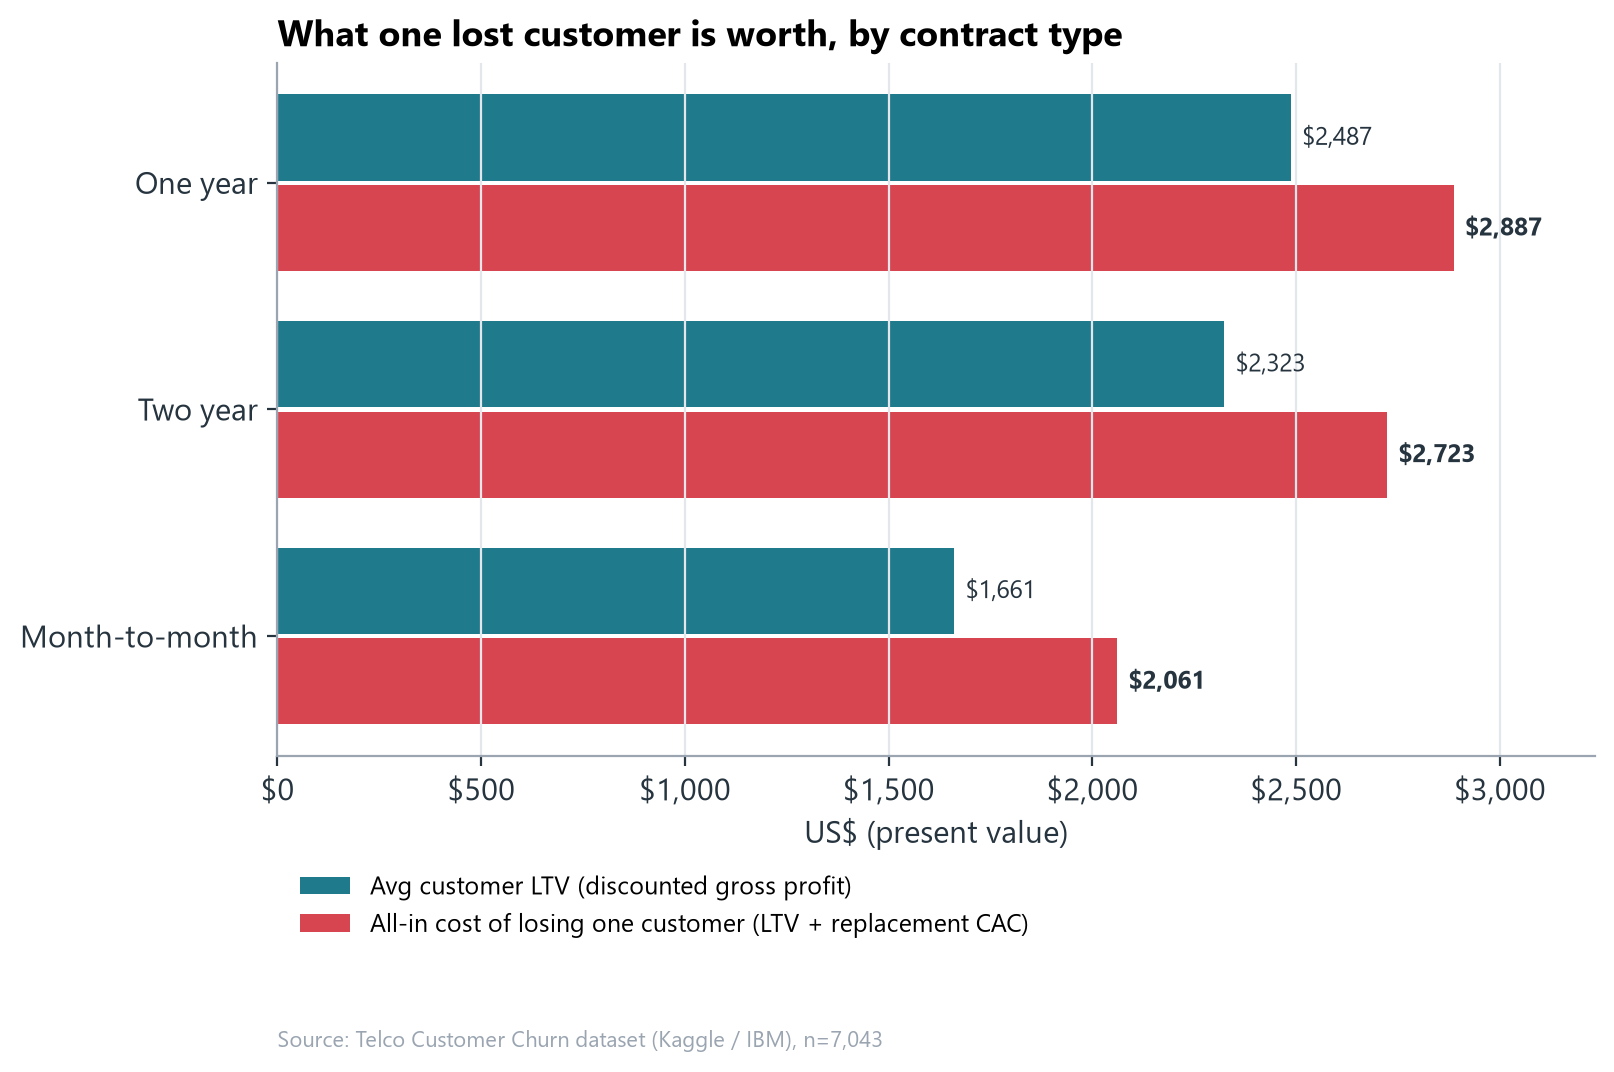

In [4]:
from src.ltv import plot_ltv_by_segment
Image(plot_ltv_by_segment(ltv))

## What the churned cohort cost

For each of the 1,869 churned customers: the discounted gross profit a comparable customer
(same contract type) would have delivered, plus a \$400 replacement CAC.

In [5]:
from src.ltv import cost_of_churn_summary

cost = cost_of_churn_summary(df)
pd.Series(cost).apply(lambda v: f"{v:,.0f}" if isinstance(v, float) else v)

churned_customers                    1,869
lost_mrr                           139,131
annualized_lost_revenue          1,669,570
foregone_ltv                     3,722,015
replacement_cac_total              747,600
total_cost_of_churn              4,469,615
avg_cost_per_churned_customer        2,391
dtype: str

Three headline framings of the same loss, in increasing order of assumptions required:

- **Lost MRR:** ~\$139K/month walked out the door (~31% of the book's \$456K MRR).
- **Annualized lost revenue:** ~\$1.67M/year if none of it is replaced.
- **Full economic cost (LTV + replacement):** **~\$4.5M** for the churned cohort.

In [6]:
from src.ltv import one_way_sensitivity, plot_sensitivity_tornado

one_way_sensitivity(df).round(0)

,assumption,low,base,high
0,Gross margin,3937899.0,4469615.0,5001332.0
1,Replacement CAC,4189265.0,4469615.0,5030315.0
2,Churn hazard,5079750.0,4469615.0,4033490.0


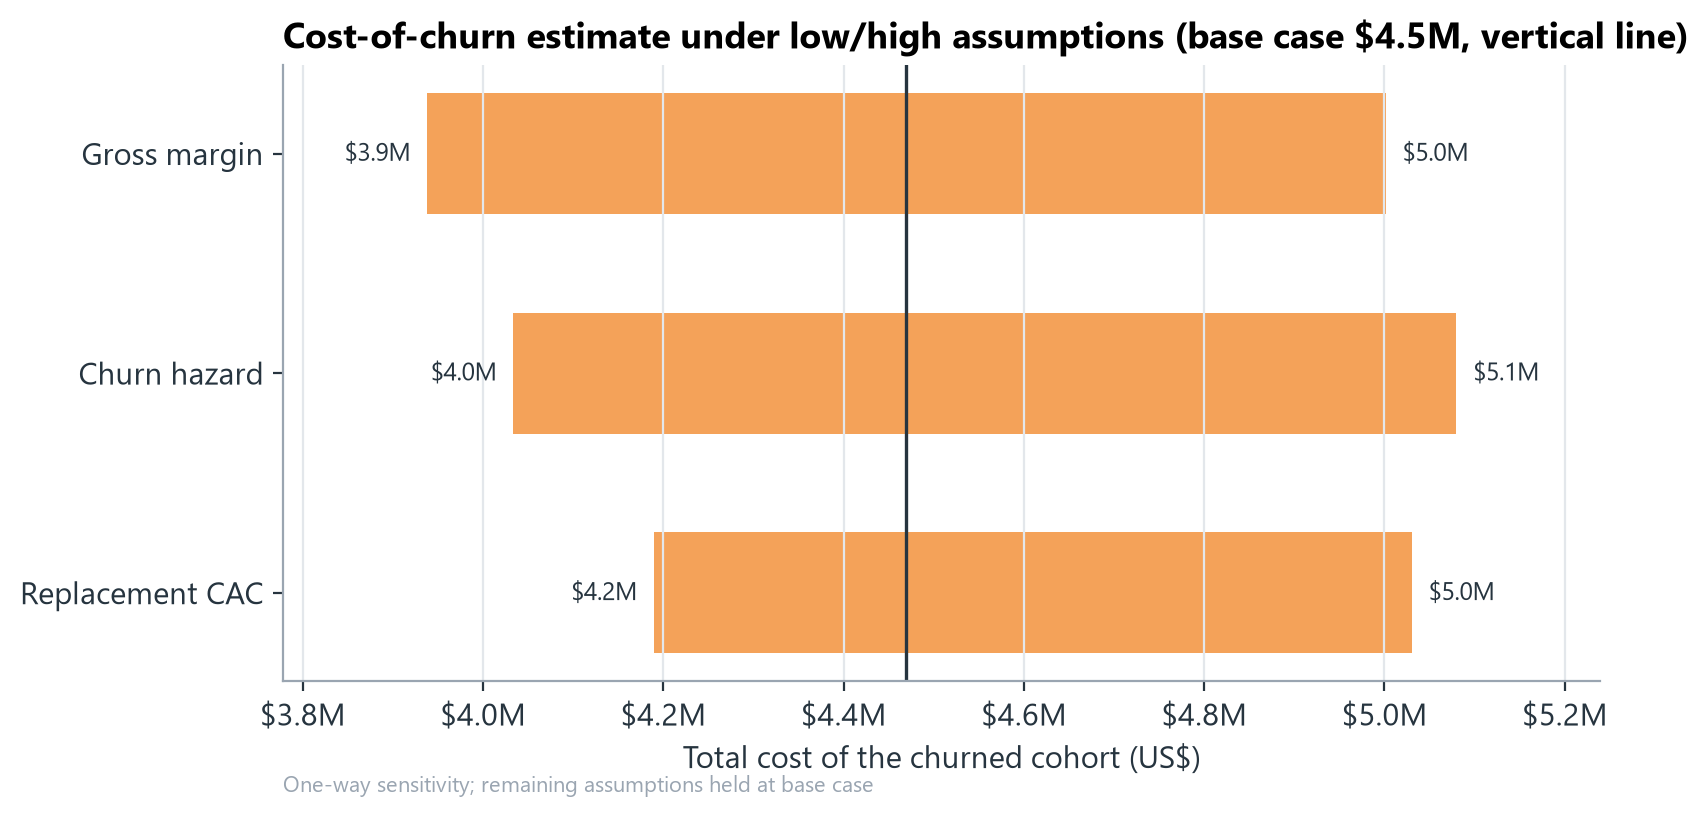

In [7]:
Image(plot_sensitivity_tornado(df))

## Reading the sensitivity

Pushing each assumption to its low/high value moves the total between **\$3.3M and \$6.3M**
(full grid) — the *magnitude* of the churn problem survives every reasonable assumption
set. The estimate is most sensitive to gross margin and the churn hazard itself, least
sensitive to CAC.

**Honest caveats** (expanded in `reports/model-report.md`): the constant-hazard assumption
smooths over front-loaded churn; the label window is unspecified so cohort-level (not
rate-level) framings are used; and margin/CAC are SaaS benchmarks, not this company's
actuals — which is exactly why they live in one config file and get a tornado chart.